# Hd5 file analysis

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd
import statistics

In [3]:
r_tot = 70774597466.3827
r_bot = 0.4 * r_tot
r_top = 0.9 * r_tot
Nr = 504
Ntheta = 360
Nphi = 720
dr_grid = (r_top - r_bot) / Nr

In [4]:
PATTERN= "post_checkpoints/*"
all_files = sorted(glob.glob(PATTERN))

In [5]:
def read_file(fname):
    print(fname)
    hf = h5py.File(fname)['Contours']
    df = pd.DataFrame(hf.get('glob_Schw_radius_envelope')[:,:,0])
    df['num_phi'] = df.index
    df = pd.melt(df, id_vars=['num_phi'], var_name='num_theta', value_name='glob_Schw')
    df['num_theta'] = df['num_theta'].astype(int)
    # df = df.set_index(['num_theta']).sort_index()
    df['conv_env'] = hf.get('pen_depth_conv_envelope')[:,:,0].T.flatten()
    df['glob_conv_env'] = hf.get('pen_depth_conv_glob_envelope')[:,:,0].T.flatten()
    df['enth_env'] = hf.get('pen_depth_enth_envelope')[:,:,0].T.flatten()
    df['glob_enth_env'] = hf.get('pen_depth_enth_glob_envelope')[:,:,0].T.flatten()
    df['vel_env'] = hf.get('pen_depth_vel_envelope')[:,:,0].T.flatten()
    df['glob_vel_env'] = hf.get('pen_depth_vel_glob_envelope')[:,:,0].T.flatten()
    df["checkpoint"] = int(fname[-9:-3])
    return df

In [5]:
all_data = pd.concat([read_file(f) for f in all_files], ignore_index=True)
all_data = all_data.set_index(["checkpoint", "num_theta"]).sort_index()

post_checkpoints\h5file_post_1dmom.002000.h5
post_checkpoints\h5file_post_1dmom.002002.h5
post_checkpoints\h5file_post_1dmom.002004.h5
post_checkpoints\h5file_post_1dmom.002006.h5
post_checkpoints\h5file_post_1dmom.002008.h5
post_checkpoints\h5file_post_1dmom.002010.h5
post_checkpoints\h5file_post_1dmom.002012.h5
post_checkpoints\h5file_post_1dmom.002014.h5
post_checkpoints\h5file_post_1dmom.002016.h5
post_checkpoints\h5file_post_1dmom.002018.h5
post_checkpoints\h5file_post_1dmom.002020.h5
post_checkpoints\h5file_post_1dmom.002022.h5
post_checkpoints\h5file_post_1dmom.002024.h5
post_checkpoints\h5file_post_1dmom.002026.h5
post_checkpoints\h5file_post_1dmom.002028.h5
post_checkpoints\h5file_post_1dmom.002030.h5
post_checkpoints\h5file_post_1dmom.002032.h5
post_checkpoints\h5file_post_1dmom.002034.h5
post_checkpoints\h5file_post_1dmom.002036.h5
post_checkpoints\h5file_post_1dmom.002038.h5
post_checkpoints\h5file_post_1dmom.002040.h5
post_checkpoints\h5file_post_1dmom.002042.h5
post_check

In [6]:
all_data

num_phi     glob_Schw      conv_env  glob_conv_env  \
checkpoint num_theta                                                       
2000       0                0  5.425350e+10  5.411308e+10   5.523648e+10   
           0                1  5.418329e+10  5.411308e+10   5.544712e+10   
           0                2  5.418329e+10  5.411308e+10   5.544712e+10   
           0                3  5.418329e+10  5.411308e+10   5.544712e+10   
           0                4  5.411308e+10  5.341095e+10   5.544712e+10   
...                       ...           ...           ...            ...   
2598       359            715  5.537691e+10  5.523648e+10   5.509606e+10   
           359            716  5.537691e+10  5.530670e+10   5.502585e+10   
           359            717  5.544712e+10  5.537691e+10   5.509606e+10   
           359            718  5.544712e+10  5.516627e+10   5.495563e+10   
           359            719  5.621946e+10  5.572797e+10   5.509606e+10   

                          enth_env  glob_enth_env       vel_env  glob_vel_env  
checkpoint num_theta                                                           
2000       0          5.411308e+10   5.523648e+10  5.383223e+10  5.509606e+10  
           0          5.411308e+10   5.544712e+10  5.362159e+10  5.516627e+10  
           0          5.411308e+10   5.544712e+10  5.348116e+10  5.523648e+10  
           0          5.411308e+10   5.544712e+10  5.348116e+10  5.544712e+10  
           0          5.341095e+10   5.544712e+10  5.341095e+10  5.544712e+10  
...                            ...            ...           ...           ...  
2598       359        5.523648e+10   5.509606e+10  5.439393e+10  5.439393e+10  
           359        5.530670e+10   5.502585e+10  5.530670e+10  5.439393e+10  
           359        5.537691e+10   5.509606e+10  5.537691e+10  5.509606e+10  
           359        5.516627e+10   5.495563e+10  5.495563e+10  5.495563e+10  
           359        5.572797e+10   5.509606e+10  5.572797e+10  5.313010e+10  

[77760000 rows x 8 columns]

### F_kin local

Mean depth [R]= 0.008409843104444072


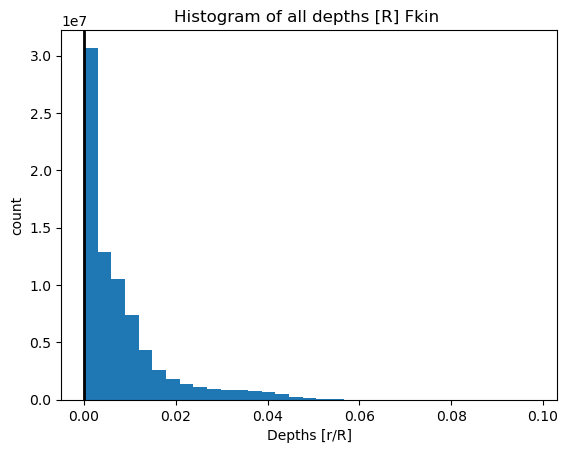

In [7]:
all_data["depth"] = (all_data["glob_Schw"] - all_data["vel_env"]) / r_tot
bins = np.arange(0.0, 0.1+dr_grid/r_tot, 3*dr_grid/r_tot)
plt.hist(all_data["depth"], bins=bins);
plt.xlabel('Depths [r/R]');
plt.ylabel('count');
plt.axvline(0.0, color="k", linewidth=2)
plt.title('Histogram of all depths [R] Fkin ')
avg=statistics.mean(all_data["depth"])
print("Mean depth [R]=",avg)

Mean max. depth [R]= 0.06535383597883433


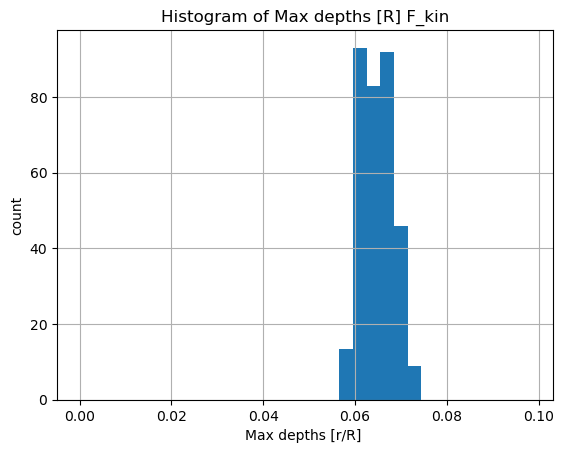

In [8]:
max_depth = all_data["depth"].groupby(level="checkpoint").max()
max_depth.hist(bins=bins, density=True)
plt.xlabel('Max depths [r/R] ');
plt.ylabel('count');
#plt.xlim(0,0.1)
plt.title('Histogram of Max depths [R] F_kin')
avg=statistics.mean(max_depth)
# avghp=statistics.mean(max_depth*r_tot/Hp_conv)
# print("Mean max. depth [R]=",avg,"  Mean max. depth [Hp_conv]=",avghp)
print("Mean max. depth [R]=",avg)

Text(0.5, 1.0, 'Max depths versus checkpoint F_kin')

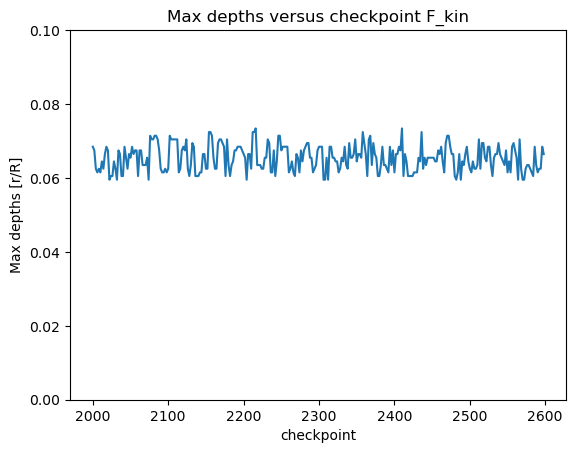

In [9]:
max_depth.plot()
plt.ylim(0,0.1)
plt.xlabel('checkpoint')
plt.ylabel('Max depths [r/R]')
plt.title('Max depths versus checkpoint F_kin')

### F_kin global Schw

Mean depth [R]= 0.008254033026425755


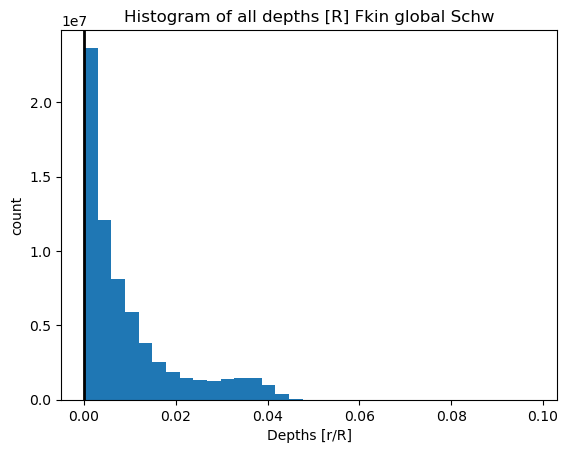

In [10]:
all_data["depth"] = (np.mean(all_data["glob_Schw"]) - all_data["glob_vel_env"]) / r_tot
bins = np.arange(0.0, 0.1+dr_grid/r_tot, 3*dr_grid/r_tot)
plt.hist(all_data["depth"], bins=bins);
plt.xlabel('Depths [r/R]');
plt.ylabel('count');
plt.axvline(0.0, color="k", linewidth=2)
plt.title('Histogram of all depths [R] Fkin global Schw')
avg=statistics.mean(all_data["depth"])
print("Mean depth [R]=",avg)

Mean max. depth [R]= 0.05772959238897267


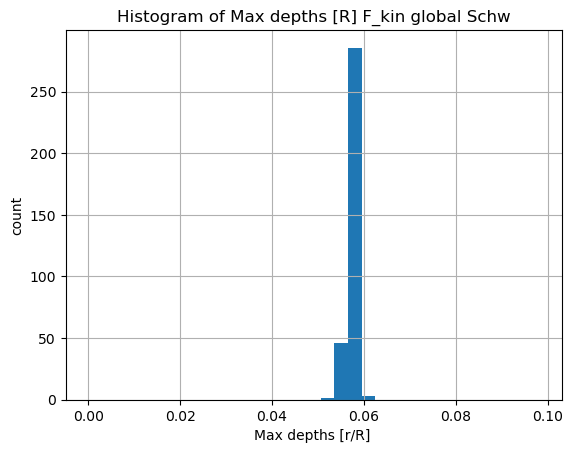

In [11]:
max_depth = all_data["depth"].groupby(level="checkpoint").max()
max_depth.hist(bins=bins, density=True)
plt.xlabel('Max depths [r/R] ');
plt.ylabel('count');
#plt.xlim(0,0.1)
plt.title('Histogram of Max depths [R] F_kin global Schw')
avg=statistics.mean(max_depth)
# avghp=statistics.mean(max_depth*r_tot/Hp_conv)
# print("Mean max. depth [R]=",avg,"  Mean max. depth [Hp_conv]=",avghp)
print("Mean max. depth [R]=",avg)

Text(0.5, 1.0, 'Max depths versus checkpoint F_kin global Schw')

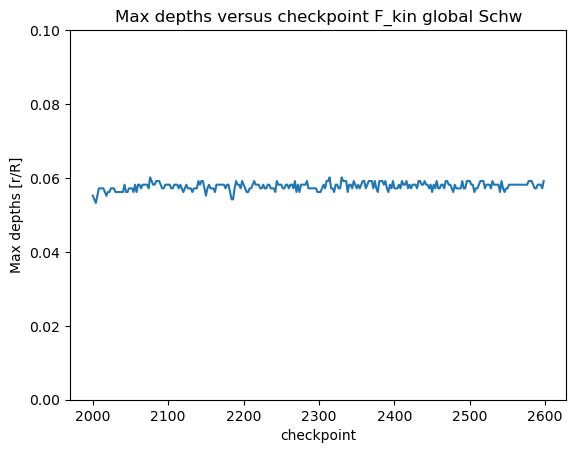

In [12]:
max_depth.plot()
plt.ylim(0,0.1)
plt.xlabel('checkpoint')
plt.ylabel('Max depths [r/R]')
plt.title('Max depths versus checkpoint F_kin global Schw')

### F_heat local

Mean depth [R]= 0.0033928900075118383


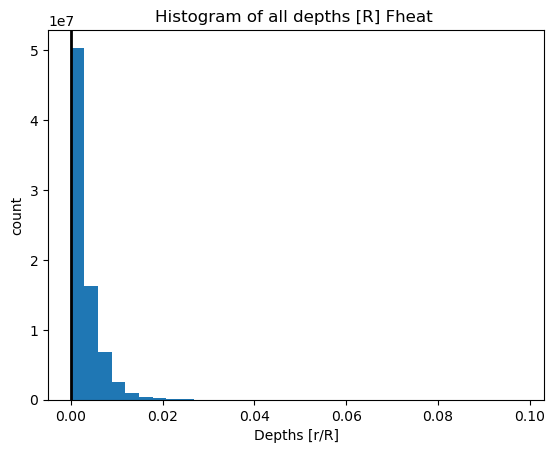

In [13]:
all_data["depth"] = (all_data["glob_Schw"] - all_data["enth_env"]) / r_tot
bins = np.arange(0.0, 0.1+dr_grid/r_tot, 3*dr_grid/r_tot)
plt.hist(all_data["depth"], bins=bins);
plt.xlabel('Depths [r/R]');
plt.ylabel('count');
plt.axvline(0.0, color="k", linewidth=2)
plt.title('Histogram of all depths [R] Fheat ')
avg=statistics.mean(all_data["depth"])
print("Mean depth [R]=",avg)

Mean max. depth [R]= 0.045476190476189345


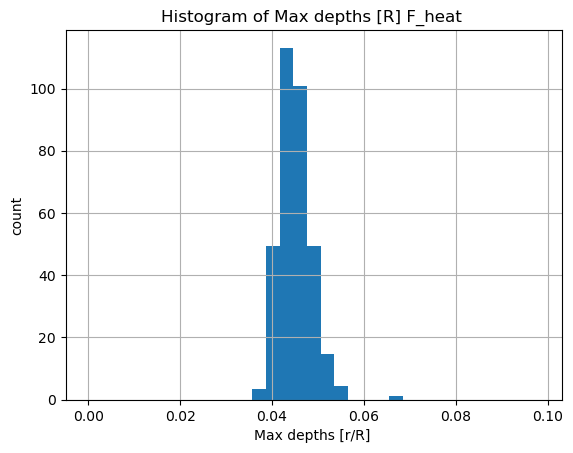

In [14]:
max_depth = all_data["depth"].groupby(level="checkpoint").max()
max_depth.hist(bins=bins, density=True)
plt.xlabel('Max depths [r/R] ');
plt.ylabel('count');
#plt.xlim(0,0.1)
plt.title('Histogram of Max depths [R] F_heat ')
avg=statistics.mean(max_depth)
# avghp=statistics.mean(max_depth*r_tot/Hp_conv)
# print("Mean max. depth [R]=",avg,"  Mean max. depth [Hp_conv]=",avghp)
print("Mean max. depth [R]=",avg)

Text(0.5, 1.0, 'Max depths versus checkpoint F_heat')

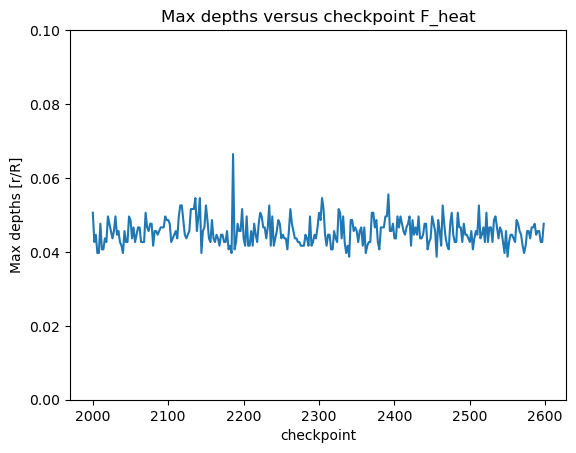

In [15]:
max_depth.plot()
plt.ylim(0,0.1)
plt.xlabel('checkpoint')
plt.ylabel('Max depths [r/R]')
plt.title('Max depths versus checkpoint F_heat')

### F_heat global Schw

Mean depth [R]= 0.0026136812776588318


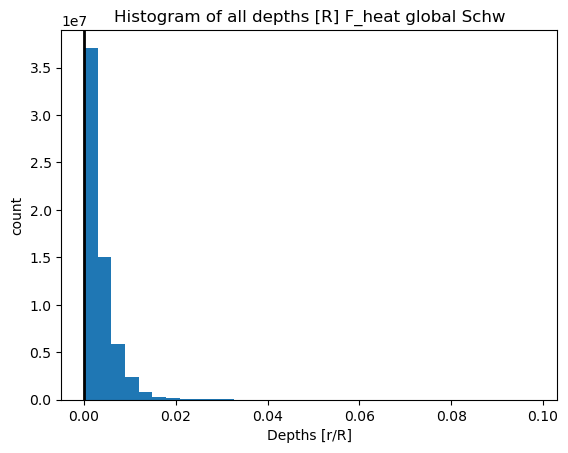

In [16]:
all_data["depth"] = (np.mean(all_data["glob_Schw"]) - all_data["glob_enth_env"]) / r_tot
bins = np.arange(0.0, 0.1+dr_grid/r_tot, 3*dr_grid/r_tot)
plt.hist(all_data["depth"], bins=bins);
plt.xlabel('Depths [r/R]');
plt.ylabel('count');
plt.axvline(0.0, color="k", linewidth=2)
plt.title('Histogram of all depths [R] F_heat global Schw')
avg=statistics.mean(all_data["depth"])
print("Mean depth [R]=",avg)

Mean max. depth [R]= 0.04148951302389373


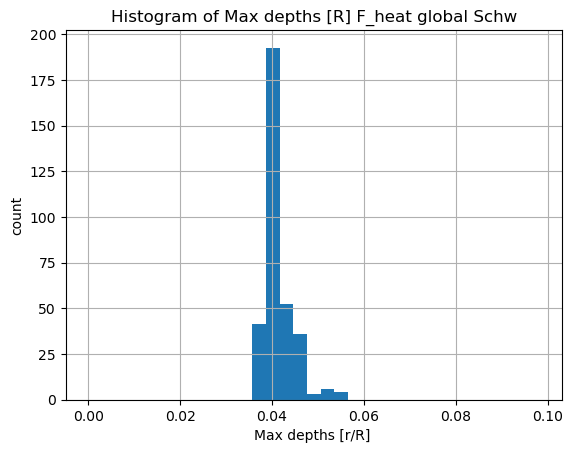

In [17]:
max_depth = all_data["depth"].groupby(level="checkpoint").max()
max_depth.hist(bins=bins, density=True)
plt.xlabel('Max depths [r/R] ');
plt.ylabel('count');
#plt.xlim(0,0.1)
plt.title('Histogram of Max depths [R] F_heat global Schw')
avg=statistics.mean(max_depth)
# avghp=statistics.mean(max_depth*r_tot/Hp_conv)
# print("Mean max. depth [R]=",avg,"  Mean max. depth [Hp_conv]=",avghp)
print("Mean max. depth [R]=",avg)

Text(0.5, 1.0, 'Max depths versus checkpoint F_heat global Schw')

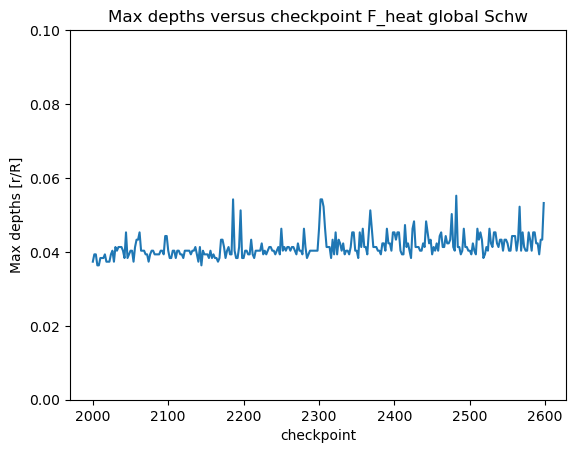

In [18]:
max_depth.plot()
plt.ylim(0,0.1)
plt.xlabel('checkpoint')
plt.ylabel('Max depths [r/R]')
plt.title('Max depths versus checkpoint F_heat global Schw')

0.781095994505369
0.7784823132277092
0.7784823132277092
0.7728419614789425


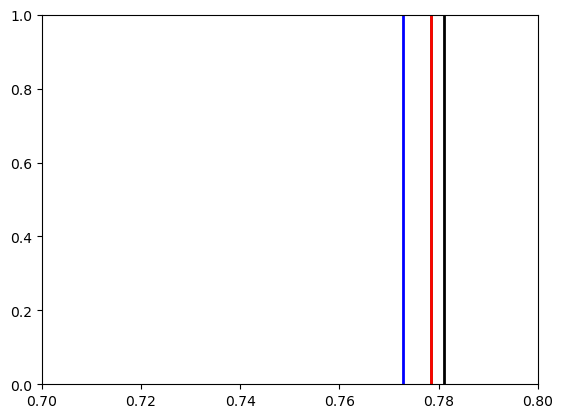

In [19]:
fig, ax = plt.subplots()
ax.set_xlim(0.7,0.8)
m = np.mean(all_data["glob_Schw"])/r_tot
print(m)
ax.axvline(m, color="k", linewidth=2)
m = np.mean(all_data["glob_conv_env"])/r_tot
print(m)
ax.axvline(m, color="g", linewidth=2)
m = np.mean(all_data["glob_enth_env"])/r_tot
print(m)
ax.axvline(m, color="r", linewidth=2)
m = np.mean(all_data["glob_vel_env"])/r_tot
print(m)
ax.axvline(m, color="b", linewidth=2)


In [20]:
file_index = 1
specific_file = all_files[file_index]
print(specific_file)

post_checkpoints\h5file_post_1dmom.002002.h5


In [21]:
df = read_file(specific_file)

post_checkpoints\h5file_post_1dmom.002002.h5


In [22]:
df

,num_phi,num_theta,glob_Schw,conv_env,glob_conv_env,enth_env,glob_enth_env,vel_env,glob_vel_env,checkpoint
0,0,0,5.418329e+10,5.411308e+10,5.523648e+10,5.411308e+10,5.523648e+10,5.390244e+10,5.516627e+10,2002
1,1,0,5.418329e+10,5.411308e+10,5.544712e+10,5.411308e+10,5.544712e+10,5.362159e+10,5.523648e+10,2002
2,2,0,5.418329e+10,5.411308e+10,5.544712e+10,5.411308e+10,5.544712e+10,5.348116e+10,5.544712e+10,2002
3,3,0,5.418329e+10,5.411308e+10,5.544712e+10,5.411308e+10,5.544712e+10,5.341095e+10,5.523648e+10,2002
4,4,0,5.411308e+10,5.341095e+10,5.544712e+10,5.341095e+10,5.544712e+10,5.341095e+10,5.530670e+10,2002
...,...,...,...,...,...,...,...,...,...,...
259195,715,359,5.628968e+10,5.558755e+10,5.446414e+10,5.558755e+10,5.446414e+10,5.446414e+10,5.446414e+10,2002
259196,716,359,5.621946e+10,5.565776e+10,5.516627e+10,5.565776e+10,5.516627e+10,5.544712e+10,5.544712e+10,2002
259197,717,359,5.621946e+10,5.565776e+10,5.544712e+10,5.565776e+10,5.544712e+10,5.551734e+10,5.544712e+10,2002
259198,718,359,5.593861e+10,5.565776e+10,5.516627e+10,5.565776e+10,5.516627e+10,5.551734e+10,5.495563e+10,2002


In [23]:
phi_slice_index = 1
df2 = df[df.num_phi == phi_slice_index]

In [24]:
df2

,num_phi,num_theta,glob_Schw,conv_env,glob_conv_env,enth_env,glob_enth_env,vel_env,glob_vel_env,checkpoint
1,1,0,5.418329e+10,5.411308e+10,5.544712e+10,5.411308e+10,5.544712e+10,5.362159e+10,5.523648e+10,2002
721,1,1,5.425350e+10,5.418329e+10,5.544712e+10,5.418329e+10,5.544712e+10,5.348116e+10,5.544712e+10,2002
1441,1,2,5.425350e+10,5.418329e+10,5.544712e+10,5.418329e+10,5.544712e+10,5.298967e+10,5.544712e+10,2002
2161,1,3,5.565776e+10,5.558755e+10,5.509606e+10,5.558755e+10,5.509606e+10,5.558755e+10,5.298967e+10,2002
2881,1,4,5.565776e+10,5.558755e+10,5.516627e+10,5.558755e+10,5.516627e+10,5.558755e+10,5.446414e+10,2002
...,...,...,...,...,...,...,...,...,...,...
255601,1,355,5.551734e+10,5.544712e+10,5.544712e+10,5.544712e+10,5.544712e+10,5.544712e+10,5.544712e+10,2002
256321,1,356,5.544712e+10,5.537691e+10,5.544712e+10,5.537691e+10,5.544712e+10,5.474499e+10,5.474499e+10,2002
257041,1,357,5.593861e+10,5.586840e+10,5.537691e+10,5.586840e+10,5.537691e+10,5.586840e+10,5.474499e+10,2002
257761,1,358,5.586840e+10,5.579819e+10,5.544712e+10,5.579819e+10,5.544712e+10,5.579819e+10,5.544712e+10,2002


In [25]:
theta_low = 30
theta_high = 150
theta_deg = theta_low + (theta_high - theta_low) * (1 + df2['num_theta']) / (Ntheta + 1)

In [26]:
depth = (df2['glob_Schw'] - df2['enth_env']) / r_tot
mean = depth.mean()

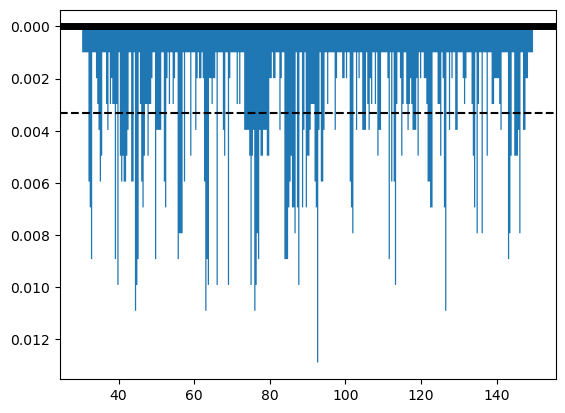

In [27]:
plt.step(theta_deg, depth, where='post', label='Step plot', alpha=0)
plt.fill_between(theta_deg, depth, step='post', alpha=1)
plt.gca().invert_yaxis()
plt.axhline(y=0,color='k',linewidth=5)
plt.axhline(y=mean,color='k',linestyle='--')

In [6]:
all_data = pd.concat([read_file(f) for f in all_files], ignore_index=True)

post_checkpoints\h5file_post_1dmom.002000.h5
post_checkpoints\h5file_post_1dmom.002002.h5
post_checkpoints\h5file_post_1dmom.002004.h5
post_checkpoints\h5file_post_1dmom.002006.h5
post_checkpoints\h5file_post_1dmom.002008.h5
post_checkpoints\h5file_post_1dmom.002010.h5
post_checkpoints\h5file_post_1dmom.002012.h5
post_checkpoints\h5file_post_1dmom.002014.h5
post_checkpoints\h5file_post_1dmom.002016.h5
post_checkpoints\h5file_post_1dmom.002018.h5
post_checkpoints\h5file_post_1dmom.002020.h5
post_checkpoints\h5file_post_1dmom.002022.h5
post_checkpoints\h5file_post_1dmom.002024.h5
post_checkpoints\h5file_post_1dmom.002026.h5
post_checkpoints\h5file_post_1dmom.002028.h5
post_checkpoints\h5file_post_1dmom.002030.h5
post_checkpoints\h5file_post_1dmom.002032.h5
post_checkpoints\h5file_post_1dmom.002034.h5
post_checkpoints\h5file_post_1dmom.002036.h5
post_checkpoints\h5file_post_1dmom.002038.h5
post_checkpoints\h5file_post_1dmom.002040.h5
post_checkpoints\h5file_post_1dmom.002042.h5
post_check

In [7]:
all_data = all_data.set_index(["num_theta"]).sort_index()

In [67]:
all_data['depth'] = (all_data['glob_Schw'] - all_data['enth_env']) / r_tot
df_combined = all_data.groupby(all_data.index).mean()

In [73]:
df_combined['theta_deg'] = theta_low + (theta_high - theta_low) * (1 + df_combined.index) / (Ntheta + 1)

In [74]:
df_combined

,num_phi,glob_Schw,conv_env,glob_conv_env,enth_env,glob_enth_env,vel_env,glob_vel_env,checkpoint,depth,theta_deg
num_theta,,,,,,,,,,,
0,359.5,5.525753e+10,5.501286e+10,5.508704e+10,5.501286e+10,5.508704e+10,5.464207e+10,5.466390e+10,2299.0,0.003457,30.33241
1,359.5,5.526279e+10,5.501728e+10,5.508320e+10,5.501728e+10,5.508320e+10,5.464595e+10,5.466286e+10,2299.0,0.003469,30.66482
2,359.5,5.527215e+10,5.502632e+10,5.507930e+10,5.502632e+10,5.507930e+10,5.465163e+10,5.465497e+10,2299.0,0.003473,30.99723
3,359.5,5.526784e+10,5.502396e+10,5.508274e+10,5.502396e+10,5.508274e+10,5.465519e+10,5.465881e+10,2299.0,0.003446,31.32964
4,359.5,5.526851e+10,5.502378e+10,5.508551e+10,5.502378e+10,5.508551e+10,5.466278e+10,5.466862e+10,2299.0,0.003458,31.66205
...,...,...,...,...,...,...,...,...,...,...,...
355,359.5,5.522020e+10,5.497701e+10,5.508560e+10,5.497701e+10,5.508560e+10,5.462611e+10,5.468460e+10,2299.0,0.003436,148.33795
356,359.5,5.522042e+10,5.498020e+10,5.508407e+10,5.498020e+10,5.508407e+10,5.463445e+10,5.467992e+10,2299.0,0.003394,148.67036
357,359.5,5.522936e+10,5.498707e+10,5.508568e+10,5.498707e+10,5.508568e+10,5.462986e+10,5.467718e+10,2299.0,0.003423,149.00277


In [70]:
mean = np.mean(df_combined['depth'])

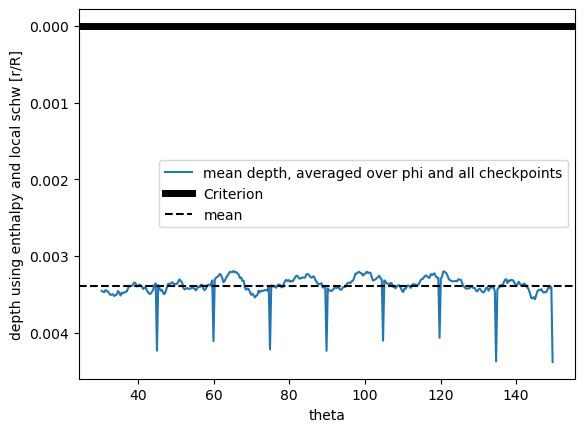

In [75]:
plt.plot(df_combined['theta_deg'], df_combined['depth'], label='mean depth, averaged over phi and all checkpoints')
plt.axhline(y=0,color='k',linewidth=5, label='Criterion')
plt.axhline(y=mean,color='k',linestyle='--', label='mean')
plt.gca().invert_yaxis()
plt.xlabel('theta')
plt.ylabel('depth using enthalpy and local schw [r/R]')
plt.legend()
plt.savefig('depth vs. theta.png')

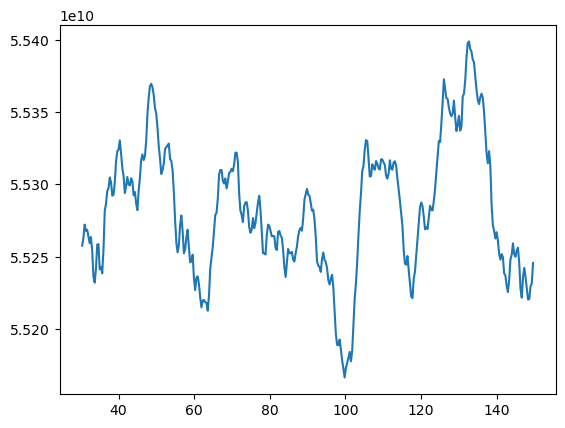

In [61]:
plt.plot(theta_deg, df_combined['glob_Schw'])

In [11]:
theta_deg = theta_low + (theta_high - theta_low) * (1 + all_data.index) / (Ntheta + 1)
depth = all_data['depth']

num_theta
0      0.001984
0      0.006944
0      0.006944
0      0.006944
0      0.015873
         ...   
359    0.003968
359    0.004960
359    0.004960
359    0.008929
359    0.006944
Name: depth, Length: 77760000, dtype: float64

In [10]:
theta_low = 30
theta_high = 150

In [30]:
min_vals = []
mean_vals = []
max_vals = []
for i in np.arange(0,360):
    vals = all_data[all_data.index == i]['depth'].values
    min_vals.append(vals.min())
    mean_vals.append(vals.mean())
    max_vals.append(vals.max())

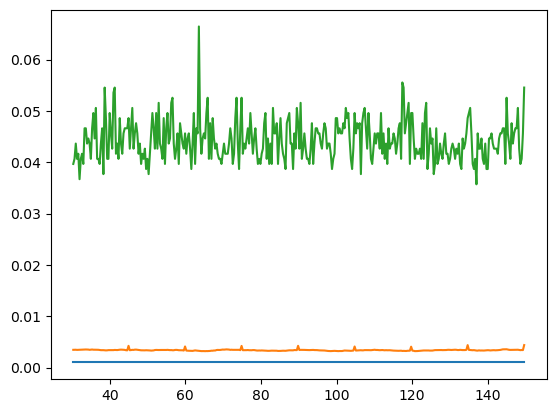

In [32]:
theta_deg = theta_low + (theta_high - theta_low) * (1 +np.arange(0,360)) / (Ntheta + 1)
plt.plot(theta_deg, min_vals)
plt.plot(theta_deg, mean_vals)
plt.plot(theta_deg, max_vals)

<Axes: >

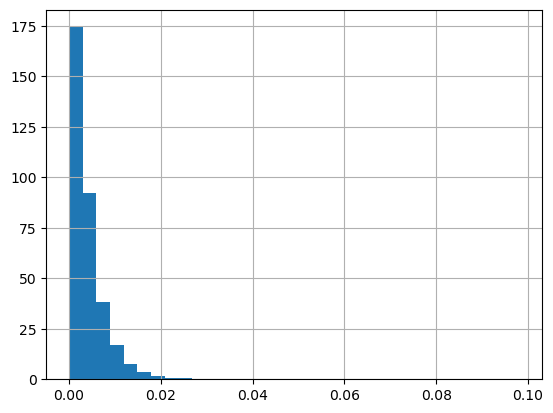

In [33]:
bins = np.arange(0.0, 0.1+dr_grid/r_tot, 3*dr_grid/r_tot)
all_data[all_data.index == 359]['depth'].hist(bins=bins, density=True)

<Axes: >

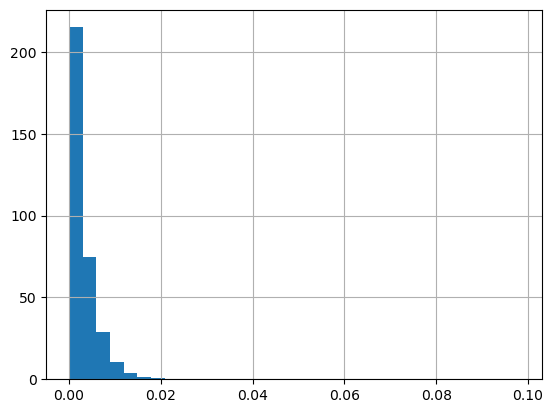

In [34]:
bins = np.arange(0.0, 0.1+dr_grid/r_tot, 3*dr_grid/r_tot)
all_data[all_data.index == 358]['depth'].hist(bins=bins, density=True)

plotting


(array([[ 37868.,  64747.,  34328., ...,   4344.,   3158.,   2273.],
        [ 37062.,  64598.,  34790., ...,   4287.,   3134.,   2283.],
        [ 37842.,  63646.,  35154., ...,   4589.,   3244.,   2263.],
        ...,
        [ 37585.,  65844.,  35900., ...,   4351.,   3109.,   2189.],
        [ 37670.,  64437.,  36048., ...,   4311.,   3009.,   2248.],
        [ 61535., 113499.,  75179., ...,  10513.,   8023.,   5630.]]),
 array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 10

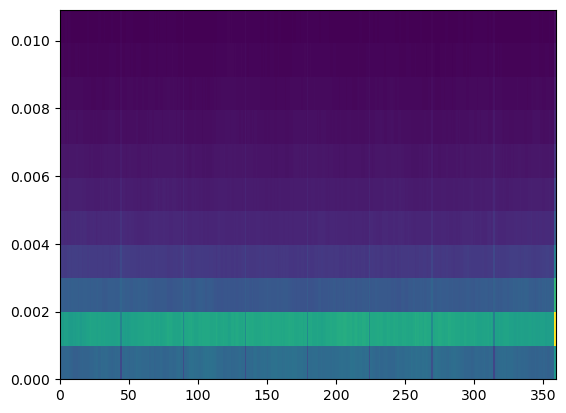

In [44]:
depth = all_data['depth']
print('plotting')
plt.hist2d(all_data.index, depth, bins=(np.arange(0,360), np.arange(0.0, 0.01+dr_grid/r_tot, dr_grid/r_tot)))


In [35]:
np.arange(theta_low, theta_high)

array([ 30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
        56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,
        69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,
        82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
        95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146,
       147, 148, 149])